In [4]:
print("Hello World!");

Hello World!


In [5]:
import sys
assert sys.version_info >=(3, 7)
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version. parse("1.0.1")

In [6]:
import os
import tarfile
from six.moves import urllib

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path= os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz= tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()
#calls a dataset/housing directory in workspace , downl the tgz. file and extracts the .csv from it 



In [7]:
import pandas as pd

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path= os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)


In [8]:
fetch_housing_data()
housing=load_housing_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [9]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [10]:
#note that total bedroom is missing some non-null values some places dont have a bedroom or in total they dont add up to one bedroom per house


In [11]:
housing["ocean_proximity"].value_counts()
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


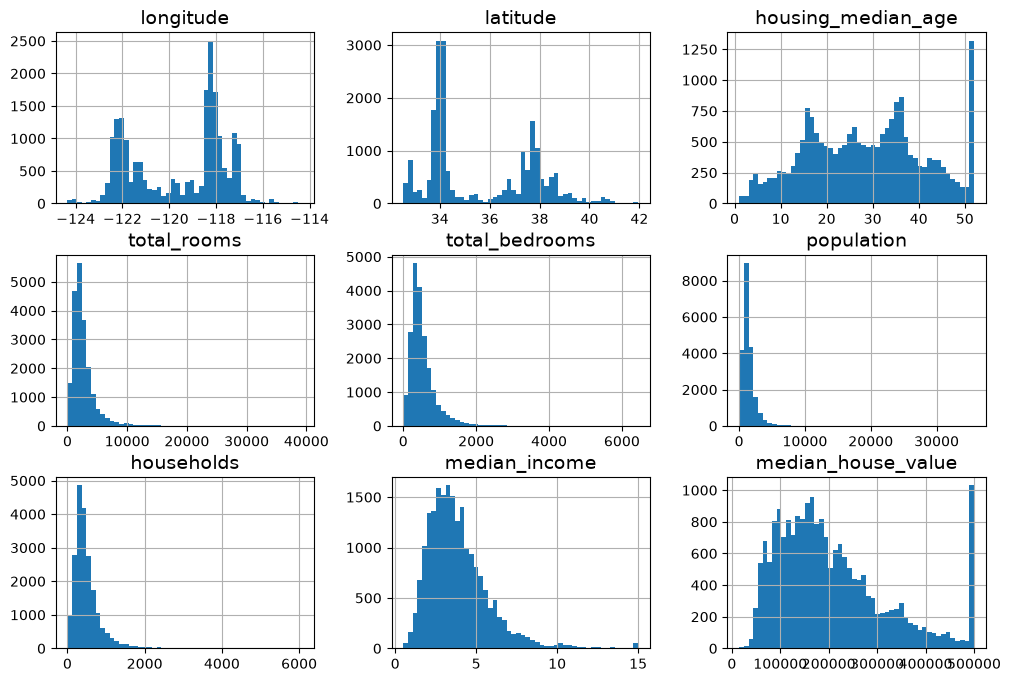

In [12]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

housing.hist(bins=50, figsize=(12, 8))
plt.show()

In [13]:
#putting a test set apart to reduce data snooping bias

import numpy as np
def split_train_test(data, test_ratio):
    shuffled_indices= np.random.permutation(len(data))
    test_set_size= int(len(data) * test_ratio)
    test_indices= shuffled_indices[:test_set_size]
    train_indices= shuffled_indices[test_set_size:]
    return data.iloc[train_indices] , data.iloc[test_indices]

train_set, test_set= split_train_test(housing, 0.2)
len(train_set)

16512

In [14]:
len(test_set)

4128

In [15]:
np.random.seed(42)

In [16]:
#Note: another source of randomness is the order of Python sets: it is based on Python's hash() function, which is randomly "salted" when Python starts up (this started in Python 3.3, to prevent some denial-of-service attacks). To remove this randomness, the solution is to set the PYTHONHASHSEED environment variable to "0" before Python even starts up. Nothing will happen if you do it after that. Luckily, if you're running this notebook on Colab, the variable is already set for you.

In [17]:
A common solution is to use each instance’s identifier to decide whether or not it should go
in the test set (assuming instances have a unique and immutable identifier). For
example, you could compute a hash of each instance’s identifier and put that instance
in the test set if the hash is lower or equal to 20% of the maximum hash value. This
ensures that the test set will remain consistent across multiple runs, even if you
refresh the dataset. The new test set will contain 20% of the new instances, but it will
not contain any instance that was previously in the training set. 

SyntaxError: invalid character '’' (U+2019) (2512291402.py, line 1)

In [18]:
from zlib import crc32

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [19]:
If you use the row index as a unique identifier, you need to make sure that new data
gets appended to the end of the dataset, and no row ever gets deleted. If this is not
possible, then you can try to use the most stable features to build a unique identifier

SyntaxError: invalid syntax (845970833.py, line 1)

In [21]:
housing_with_id = housing.reset_index()  # adds an `index` column

In [22]:
#For example, a district’s latitude and longitude are guaranteed to be stable for a few
#million years, so you could combine them into an ID 

housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "id")

NameError: name 'split_train_test_by_id' is not defined

In [23]:
#skitlearn
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

In [26]:
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

In [27]:
#stratified shuffle
from sklearn.model_selection import StratifiedShuffleSplit

splitter= StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(housing, housing["income_cat"]):
    strat_train_set_n = housing.iloc[train_index]
    strat_test_set_n= housing.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

strat_train_set, strat_test_set= strat_splits[0]

strat_test_set["income_cat"].value_counts() / len(strat_test_set)


income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [29]:
#copy
housing = strat_train_set.copy()


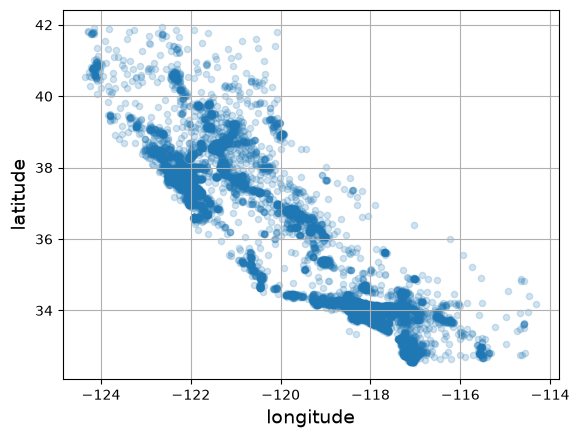

In [30]:
housing.plot(kind="scatter", x="longitude", y= "latitude" , grid= True, alpha=0.2)
plt.show()

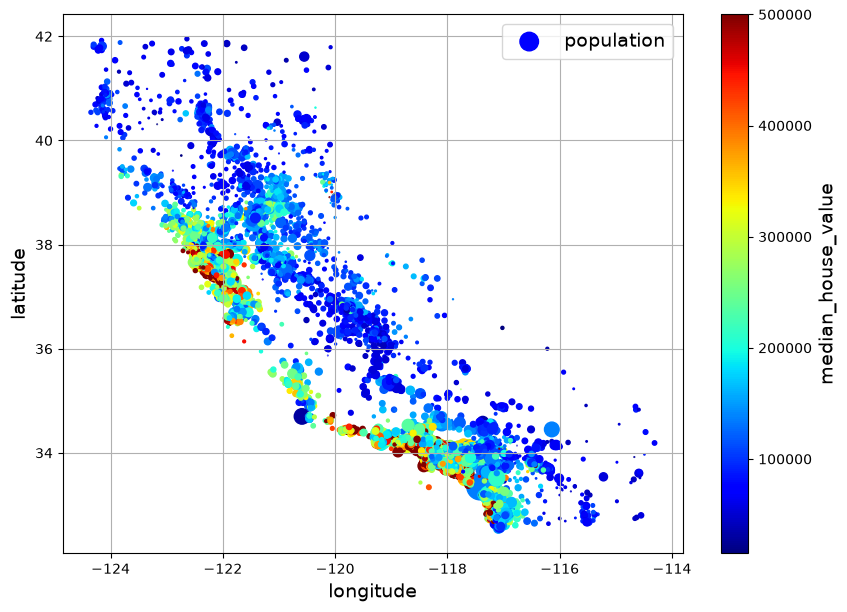

In [33]:
#extra stuff

housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
plt.show()

In [36]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

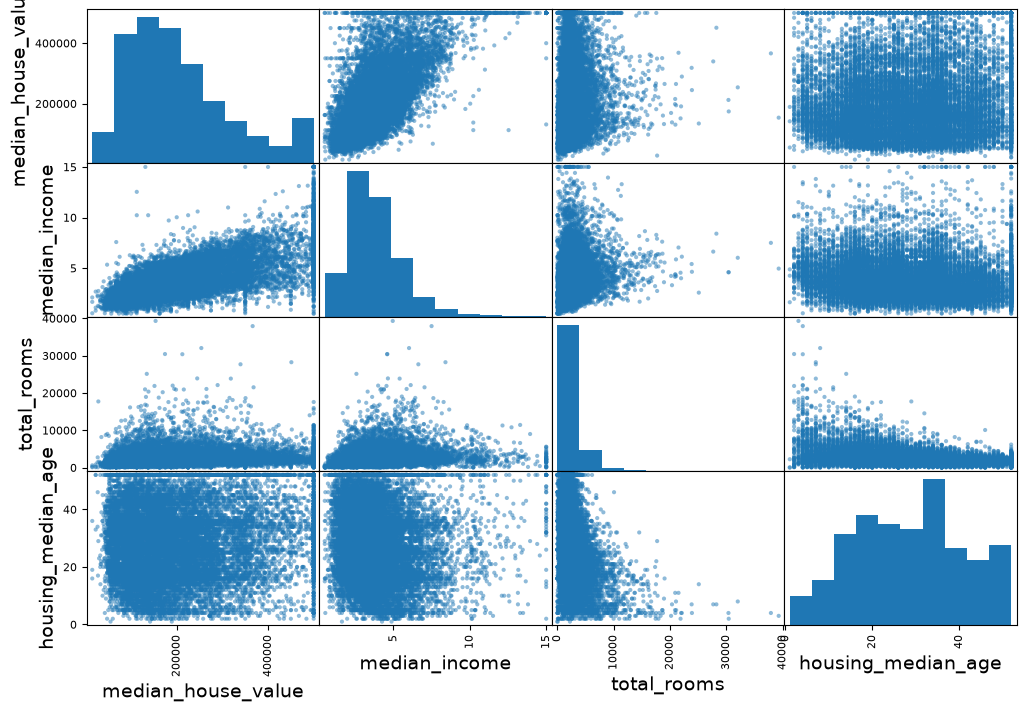

In [37]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms",
"housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))

<Axes: xlabel='median_income', ylabel='median_house_value'>

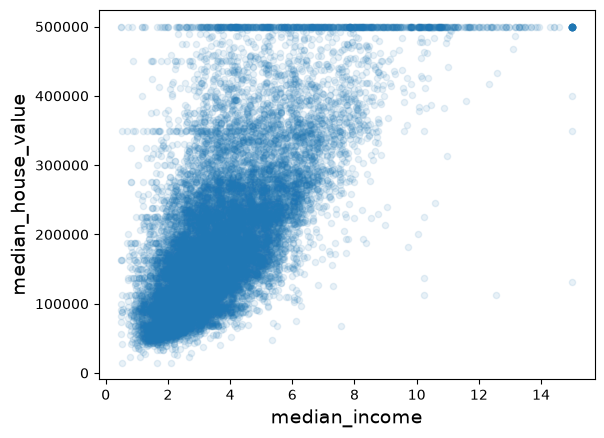

In [38]:
#most promising is income to house value
housing.plot(kind="scatter", x="median_income", y="median_house_value",
alpha=0.1)

In [ ]:
#Prepare the Data

housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [ ]:
# THere exists a handly class by sckit-learn to take care of missing values: Simple Imputer
#to use it first createa instance
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")


In [ ]:
#imputer can only be used on numerical atrributes to screate a copy of data without ocean_proximity
housing_num= housing.drop("ocean_proximity", axis=1)
imputer.fit(housing.num)
imputer.statistics_


In [ ]:
#applying this is the same as just turning housenum and calcualting median of all values similar to what you see below
housing_num.median().values

In [ ]:
X = imputer.transform(housing_num)

In [ ]:
#turns into a numpy array instead of being back into a pandas data frame


In [ ]:
#easily acess the names of the array given by trasnformer
imputer.feature_names_in_

In [ ]:
#DROp outliers code
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(random_state=42)
outlier_pred = isolation_forest.fit_predict(X)


In [ ]:
outlier_pred

In [ ]:
#HANDLING TEXT AND CATEOGIRICAL ATTRIBUTES

In [ ]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

In [ ]:
from scklearn.preprocessing import OrdinalEncoder
original_encoder= OrdinalEncoder()
housing_cat_encoded = original_encoder.fit_transform(housing.cat)

In [ ]:
housing_cat_encoded[:8]

In [ ]:
ordinal_encoder.categories_

In [ ]:
#THe onehot encoder for trasnformation
from sklearn.preprocessing import OneHotEncoder

cat_encoder= OneHotEncoder()
housing_cat_1hot= cat_encoder.fit_transform(housing_cat)

In [ ]:
housing_cat_1hot

In [ ]:
#once again you can see original encoders catrogires
cat_encoder.categories_

In [ ]:
df_test = pd.DataFrame({"ocean_proximity": ["INLAND", "NEAR BAY"]})
pd.get_dummies(df_test)

In [1]:
# Custom Transformers
#EXAMPLE BELOW

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

rooms_ix, bedrooms_ix, population_ix, household_ix = 3,4,5,6

class CombinedAtrributedAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True): #no *args or **kargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y= None) :
        return self #nothing else needed
    def transform(self, X, y= None):
        rooms_per_household= X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room= X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c[X, rooms_per_household, population_per_household]

    attr_adder = CombinedAttributesAdder(add_bedrooms_per_room = False)
    housing_extra_attribs = attr_adder.transform(housing.values)

#HYPERPARAMATER IS  add_bedrooms_per_room set to true by defualt 

#this style helps turn on or off data preparations steps that can lead to better combinations

In [ ]:
#Data trasnfromation need to be done in right order, skitlearn provides the class to help with right sequence of trasnformations

In [ ]:
from sklearn.pipelime import Pipeline 
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([ 
    ('imputer' , SimpleImputer(strategy= "media")),
    ('attribs_adder', CombinedAttributesAdder()), 
    ('std_scaler' , StandardScaler()),
])

housing_num_tr= num_pipeline.fit_transform(housing_num)

In [ ]:
#This handles what we are trasnforming and preprocessing for one category one columns and nothing else, what if we had more to do 
# Column Transformer handles adding all the appropriate transformations to each of these columns

from sklearn.compose import ColumnTransformer
num_attribs= list(housing_num)
cat_attribs= ["ocean_proximity"]

full_pipiline = ColumnTransformer([
    ("num", num_pipeline, num_attribs), 
    ("cat", OneHotEncoder(), cat_attribs),
])

housing_prepared= full_pipeline.fit_transform(housing)

In [ ]:
#Selecting and Training Model : Training and Evaluating on the Training Set

In [ ]:
from sklearn.linear_model import LinearRegression
lin_reg= LinearRegression()
line_reg.fit(housing_prepared, housing_labels) #housing prepared is our full pipeline

In [ ]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)

print("Predictions:", lin_reg.predict(some_data_prepared))

In [ ]:
print("Labels:", list(some_labels))

In [ ]:
# we get to se ehow close , we can calcuate RMSE using meansqaured error function
from sklearn.metrics import mean_squared_error
housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

In [ ]:
#Three improvements for underffiting - more powerful model, better features, or reducing constraints on the model

In [ ]:
#We select a more powerful model, DecisionTreeRegressor- capable of finding complex nonlinear relationships in data
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)

In [ ]:
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

In [ ]:
#Evaluating the model using cross-validation
#Here we could split the training set but instrad we use ScitkitLearns K-Fold cross validation feature , splitting the set into folds then picking a fold
#and then testing against another fold a K amount of times
#results in a array with 10 evaluation scores



In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(tree_reg, housing_prepared, housing_labels,
    scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

In [ ]:
#lets see them
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(tree_rmse_scores)

In [ ]:
#one last model RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
forest_reg= RandomForestRegressor()
forest.reg.fit(housing_prepared, housing_labels)
forest_rmse

In [ ]:
from sklearn.model_selection import cross_val_score

forest_scores = cross_val_score(forest_reg, housing_prepared, housing_labels,
                                scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

In [ ]:
#Save model
from sklearn.externals imprt joblib

joblib.dump(my_model, "my_model.pkl")
# toload model
my_model_loaded = joblib.load("my_model.pkl")


In [ ]:
#fine tuning model

# Grid search to fiddle with hyperparameters here looking for best of randomforest
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'n_estimators' : [3,10,30] , 'max_features' : [2,4,6,8]},
    {'boostrap': [False], 'n_estimators' : [3,10], 'max_features' : [2,3,4]},
]

forest_reg= RandomForestRegressor()

grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring = 'neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(housing_prepared, housing_labels)

In [ ]:
grid_search.best_params_

In [ ]:
#best estimator directly
grid_search.best_estimator_

In [ ]:
#take a look at the evaluation scors
cvres=grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

In [ ]:
#Analyzing the best models importance and errors
feature_importances= grid_search.best_estimator_.feature_importances_

In [ ]:
feature_importances

In [ ]:
extra_attribs = ["rooms_per_hhold", "pop_per_hhold", "bedrooms_per_room"]
#cat_encoder = cat_pipeline.named_steps["cat_encoder"] # old solution
cat_encoder = full_pipeline.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attribs + extra_attribs + cat_one_hot_attribs
sorted(zip(feature_importances, attributes), reverse=True)

In [ ]:
#Finally evaluate on the test set
final_model = grid_search.best_estimator_
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()
X_test_prepared = full_pipeline.transform(X_test)
final_predictions = final_model.predict(X_test_prepared)
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse) 

In [ ]:
#Estimate a generalization error of 95% confidence using scipy.stats.t.interval() 
from scipy import stats

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
                         loc=squared_errors.mean(),
                         scale=stats.sem(squared_errors)))

In [ ]:
#these are numbers you have to okay with NEVER finetune to the new test data , it sunlikely to work well on new test sets.


In [ ]:
#Launching, Monitoring, and Maintainig a SYstem
# * Monitoring Code as to know live performance and trigger alerts when not meeting benchmarks
# * Evaluating perfromance means sampling predictions and having more thorough analysis - reocomended to be done by humans
# * Evaluate input data quality will protect from system degrade that happens over time , fresh input = fresh output
# * Training on a regular basis and saving these statses helps with rollback and recording performance.

In [ ]:
#EXERCISES TO be tried on in /personalhandsonml
Exercises
Using this chapter’s housing dataset:
1. Try a Support Vector Machine regressor (sklearn.svm.SVR), with various hyper
parameters such as kernel="linear" (with various values for the C hyperpara
meter) or kernel="rbf" (with various values for the C and gamma
hyperparameters). Don’t worry about what these hyperparameters mean for now.
How does the best SVR predictor perform?
2. Try replacing GridSearchCV with RandomizedSearchCV.
3. Try adding a transformer in the preparation pipeline to select only the most
important attributes.
4. Try creating a single pipeline that does the full data preparation plus the final
prediction.
5. Automatically explore some preparation options using GridSearchCV.

In [ ]:
#FINAL